In [1]:
from graphen import grphn
import numpy as np
import matplotlib.pyplot as plt


data = np.loadtxt('DOSNbin1000.txt')
G = grphn()
k = G.k_Bev

In [2]:
G.v_F_hbr * 6*1e-5 *1000

np.float64(0.35783999999999994)

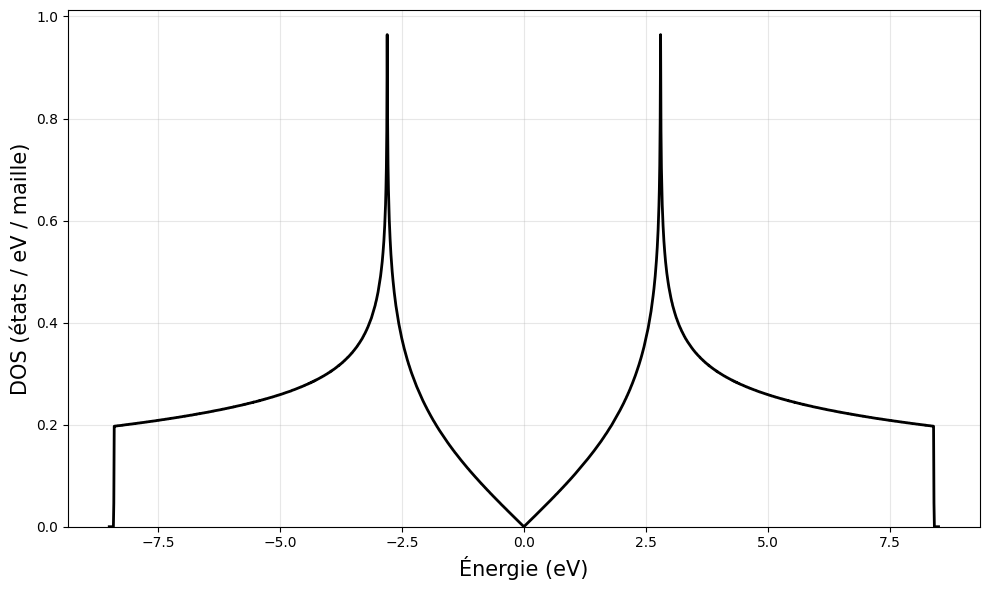

In [3]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.plot(data[:,0],data[:,1], linewidth=2,color='black')

axes.set_xlabel('Énergie (eV)', fontsize=15)
axes.set_ylabel('DOS (états / eV / maille)', fontsize=15)
# axes.set_title('Densité d\'états du graphène', fontsize=14)
axes.grid(True, alpha=0.3)
axes.set_ylim(bottom=0)
# axes.legend()
plt.tight_layout()
plt.savefig('DOS1000.jpg',dpi=600)
plt.show()

In [4]:
def f_p(E_ev,kT_ev,Flvl_ev):
    return 1/(2*kT_ev)* 1/(1+np.cosh((E_ev-Flvl_ev)/kT_ev))

/tmp/ipykernel_35338/1346869014.py:2: RuntimeWarning: overflow encountered in cosh
  return 1/(2*kT_ev)* 1/(1+np.cosh((E_ev-Flvl_ev)/kT_ev))


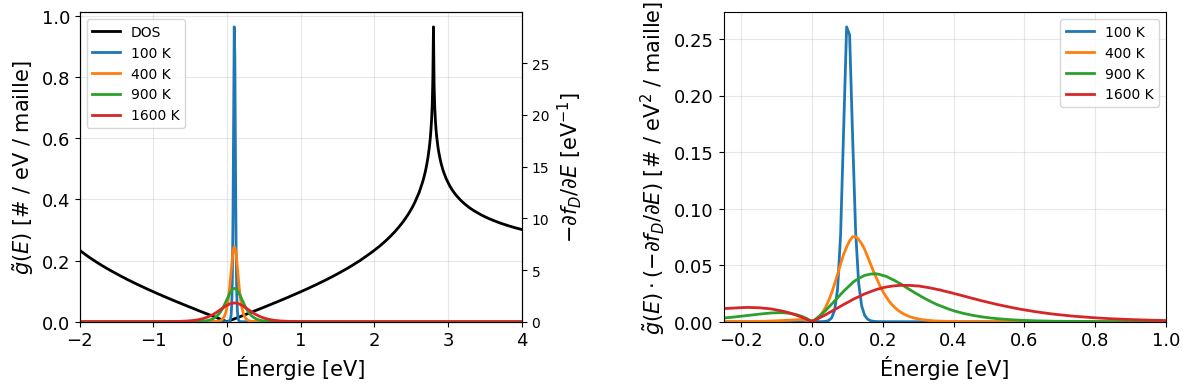

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

T = np.arange(10, 50, 10)**2
F_lvl = 0.1


# 1. DOS (Axe Y de gauche)
axes[0].plot(data[:,0], data[:,1], linewidth=2, color='black', label='DOS')
axes[0].set_xlabel('Énergie [eV]', fontsize=15)
axes[0].set_ylabel(r'$\tilde{g}(E)$ [# / eV / maille]', fontsize=15)
axes[0].set_xlim(-2, 4)
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)

# 2. Variation de FD (Axe Y de droite, avec twinx)
ax_twin = axes[0].twinx()
for t in T:
    sig_p = f_p(data[:,0], t*k, F_lvl)
    ax_twin.plot(data[:,0], sig_p, linewidth=2, label=f'{t} K')
    
ax_twin.set_ylabel(r'$-\partial f_D/\partial E$ [eV$^{-1}$]', fontsize=15)
ax_twin.set_ylim(bottom=0)  # Tu avais mis cette limite, je l'applique ici.

# Légende commune pour left & right
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax_twin.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# =======================================================
# AXE DROITE (axes[1]) : Produit des deux
# =======================================================
for t in T:
    sig_p = f_p(data[:,0], t*k, F_lvl)
    axes[1].plot(data[:,0], sig_p*data[:,1], linewidth=2, label=f'{t} K')
    
axes[1].set_xlabel('Énergie [eV]', fontsize=15)
axes[1].set_ylabel(r'$\tilde{g}(E) \cdot (-\partial f_D/\partial E)$ [# / eV$^2$ / maille]', fontsize=15)
axes[1].set_xlim(-1/4, 1)
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()


axes[1].tick_params(axis='both', which='both', labelsize=13)
axes[0].tick_params(axis='both', which='both', labelsize=13)
plt.tight_layout(w_pad=4.0)



plt.savefig('TempEffectQC.jpg', dpi=600)
plt.show()

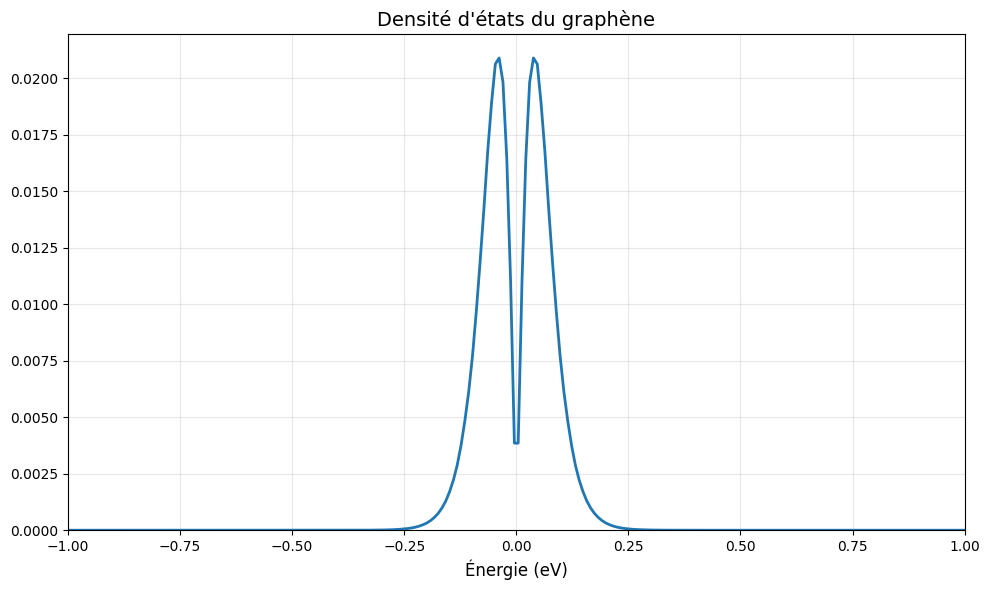

In [15]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

T=300
F_lvl = 0
sig_p = f_p(data[:,0],T*k,F_lvl)
axes.plot(data[:,0],sig_p*data[:,1], linewidth=2)

axes.set_xlabel('Énergie (eV)', fontsize=12)
# axes.set_ylabel('DOS (états / eV / maille)', fontsize=12)
axes.set_title('Densité d\'états du graphène', fontsize=14)
axes.grid(True, alpha=0.3)
axes.set_ylim(bottom=0)
axes.set_xlim(-1, 1)
# axes.legend()
plt.tight_layout()
plt.show()

In [3]:
dataconv = np.loadtxt('ConvNbin1000.txt')

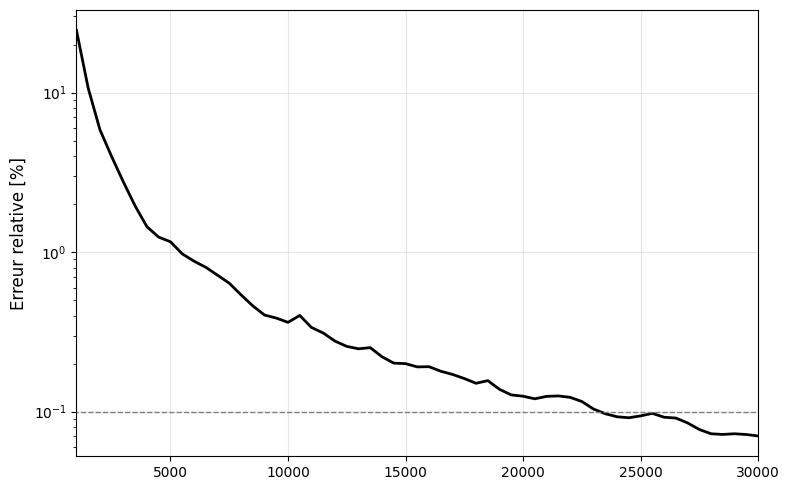

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.semilogy(dataconv[:,0],dataconv[:,1]*100, linewidth=2,color='black')
axes.hlines(1e-1,-100,30100,linewidth=1,linestyles='--',colors='grey')

axes.set_ylabel('Erreur relative [%]', fontsize=12)
# axes.set_xlabel('', fontsize=12)
# axes.set_title('Densité d\'états du graphène', fontsize=14)
axes.grid(True, alpha=0.3)

axes.set_xlim((dataconv[0,0],dataconv[-1,0]))
plt.tight_layout()
plt.savefig('convUni.jpg',dpi=600)

plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

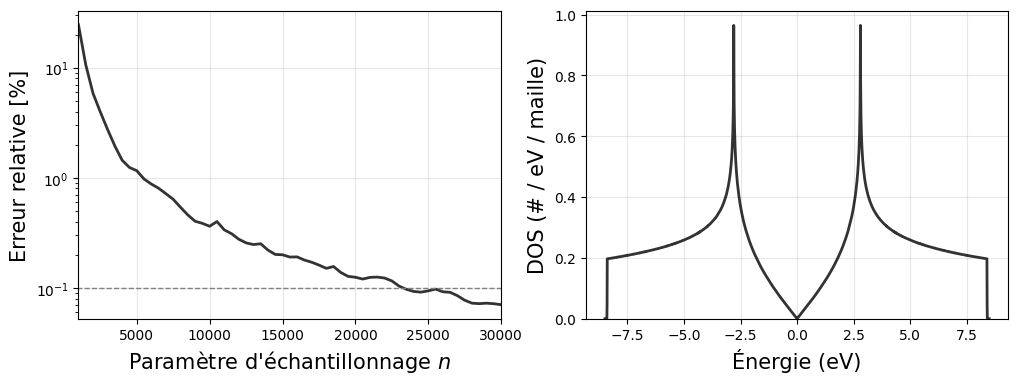

In [ ]:
E_f = 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[1].plot(data[:,0],data[:,1], linewidth=2,color="black",alpha=0.8)
axes[1].set_xlabel('Énergie (eV)', fontsize=15)
axes[1].set_ylabel('DOS (# / eV / maille)', fontsize=15)
# axes.set_title('Densité d\'états du graphène', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(bottom=0)


axes[0].semilogy(dataconv[:,0],dataconv[:,1]*100, linewidth=2,color="black",alpha=0.8)
axes[0].hlines(1e-1,-100,30100,linewidth=1,linestyles='--',colors='grey')

axes[0].set_ylabel('Erreur relative [%]', fontsize=15)
axes[0].set_xlabel("Paramètre d'échantillonnage $n$", fontsize=15)
# axes.set_title('Densité d\'états du graphène', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[0].set_xlim((dataconv[0,0],dataconv[-1,0]))
axes[1].fill_between(data[:,0][data[:,0]>0 and data[:,0]<E_f], 0, data[:,1][data[:,0]>0 and data[:,0]<E_f], alpha=0.3, color='g')
axes[1].fill_between(data[:,0][data[:,0]<0], 0, data[:,1][data[:,0]<0], alpha=0.3, color='grey')
axes[1].tick_params(axis='both', which='both', labelsize=13)
axes[0].tick_params(axis='both', which='both', labelsize=13)

plt.tight_layout(w_pad=4.0)
plt.savefig('DOS&conv.jpg',dpi=600)

plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import concurrent.futures
import multiprocessing
import scipy.special as sp


def _compute_chunk(kx_chunk, ky_array, b, a_1, a_2, t, E_levels):
    """Calcule l'histogramme pour un sous-bloc de la grille kx."""
    kxx, kyy = np.meshgrid(kx_chunk, ky_array)

    # Masque FBZ
    radius_k = b / np.sqrt(3)
    mask = (np.abs(kxx) <= radius_k * np.sqrt(3) / 2) & \
           (np.abs(np.sqrt(3) * kyy + kxx) <= radius_k * np.sqrt(3)) & \
           (np.abs(np.sqrt(3) * kyy - kxx) <= radius_k * np.sqrt(3))

    # Astuce RAM : On extrait uniquement les points valides (vecteurs 1D)
    kxx_m = kxx[mask]
    kyy_m = kyy[mask]
    n_k_chunk = len(kxx_m)

    # Calcul TB sur les bons points uniquement
    e1 = np.exp(-1j * (kxx_m * a_1[0] + kyy_m * a_1[1]))
    e2 = np.exp(-1j * (kxx_m * a_2[0] + kyy_m * a_2[1]))
    CB_masked = np.abs(t) * np.abs(1 + e1 + e2)

    # Histogramme
    hist, _ = np.histogram(CB_masked, bins=E_levels)
    
    return hist, n_k_chunk

class grphn():
    def __init__(self):
        # Constantes de base
        self.h = 6.626e-34
        hbar = self.h / (2*np.pi)
        self.hbarr = 1
        self.t = 2.7 # eV
        self.d = 1.42 # A
        self.a = np.sqrt(3) * self.d
        self.b = 4*np.pi / (np.sqrt(3)*self.a)
        
        # Vecteurs
        self.a_1 = np.array([np.sqrt(3)/2, -1/2]) * self.a
        self.a_2 = np.array([np.sqrt(3)/2, 1/2]) * self.a
        self.b_1 = np.array([1/np.sqrt(3), -1]) * (2*np.pi/self.a)
        self.b_2 = np.array([1/np.sqrt(3), 1]) * (2*np.pi/self.a)
        
        self.S = self.a**2 * np.sqrt(3) / 2
        self.v_F = self.t * np.sqrt(3) * self.a / (2*hbar)
        self.v_F_hbr = self.t * np.sqrt(3) * self.a / 2

    def DOS_Dirac_ana(self, E_array):
        # Formule analytique exacte
        hv_F = self.hbarr * self.v_F_hbr
        return (np.abs(E_array) * 2 * self.S) / (np.pi * hv_F**2)

    def DOS_parallel(self, n_points=5000, n_bins=3000, E_max=None, chunk_size=200):
        if E_max is None:
            E_max = 3 * self.t

        kx_array = np.linspace(-self.b, self.b, n_points)
        ky_array = np.linspace(-self.b, self.b, n_points)
        
        E_levels = np.linspace(0, E_max, n_bins + 1)
        DOSp_accumulated = np.zeros(n_bins)
        
        n_k_FBZ_total = 0 
        chunks = [kx_array[i : i+chunk_size] for i in range(0, n_points, chunk_size)]
        
        n_cores = multiprocessing.cpu_count()
        print(f"-> Début calcul DOS sur {n_cores} cœurs (n_points={n_points})...")

        with concurrent.futures.ProcessPoolExecutor(max_workers=n_cores) as executor:
            futures = [executor.submit(_compute_chunk, chk, ky_array, self.b, self.a_1, self.a_2, self.t, E_levels) for chk in chunks]
            
            for future in concurrent.futures.as_completed(futures):
                hist, n_k = future.result()
                DOSp_accumulated += hist
                n_k_FBZ_total += n_k

        self.n_k_FBZ = n_k_FBZ_total

        dE = E_levels[1] - E_levels[0]
        norm_factor = 2 / (self.n_k_FBZ * dE) 
        DOSp = DOSp_accumulated * norm_factor
        
        DOSm = DOSp[::-1]
        self.DOS = np.concatenate([DOSm, DOSp])
        
        E_centers_p = (E_levels[:-1] + E_levels[1:]) / 2
        self.E_DOS = np.concatenate([-E_centers_p[::-1], E_centers_p])
        
        print("-> Fin du calcul !")
        return self.E_DOS, self.DOS, DOSp

In [ ]:
# 1. Instanciation
graphene = grphn()

# 2. Lancement du calcul super rapide
# Test avec 6000 points (ça équivaut à une grille de 36 millions de points !)
graphene.DOS_parallel(n_points=90000, n_bins=350,E_max=2)

# 3. Récupération pour l'affichage (côté énergie positive)
mask = graphene.E_DOS >= 0
E_pos = graphene.E_DOS[mask]
DOS_pos = graphene.DOS[mask]
DOS_ana = graphene.DOS_Dirac_ana(E_pos)

er = np.abs(DOS_pos-DOS_ana)/np.abs(DOS_pos) *100

Calcul de de la DOS sur 16 cœurs (n_points=90000)...


In [29]:
# np.savetxt(f'DOS350_90000.txt', np.column_stack((E_pos, DOS_pos)), 
#            header=f'E[eV] | DOS[1/(eV maille)]', 
#            fmt='%.6f')
data = np.loadtxt('DOS350_90000.txt')

/tmp/ipykernel_26531/2111211764.py:7: RuntimeWarning: divide by zero encountered in divide
  er = np.abs(DOS_pos-DOS_ana)/np.abs(DOS_pos) *100


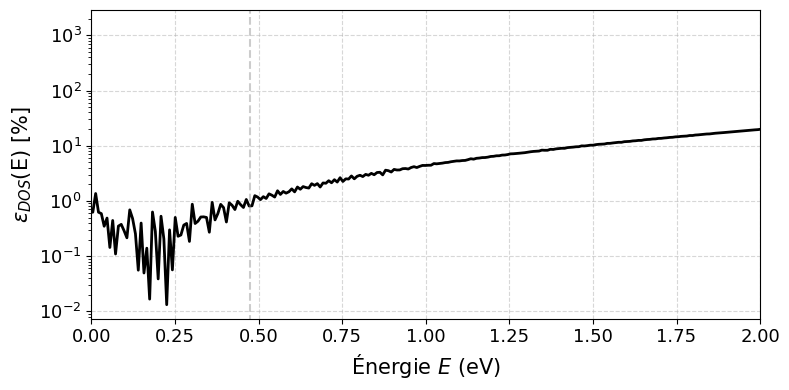

In [34]:
# 4. Tracé du graphe de vérification
graphene = grphn()
plt.figure(figsize=(8, 4))
E_pos = data[:,0]
DOS_pos = data[:,1]
DOS_ana = graphene.DOS_Dirac_ana(E_pos)
er = np.abs(DOS_pos-DOS_ana)/np.abs(DOS_pos) *100
# plt.plot(E_pos, DOS_pos, color='#464c89', lw=2, label="Tight-Binding (Multicoeur)")
# plt.plot(E_pos, DOS_ana, color='#ff6b59', lw=2, linestyle='--', label="Cône de Dirac (Analytique)")

plt.semilogy(E_pos,er, color='black', lw=2)

# On marque la singularité de Van Hove
# plt.axvline(x=2.7, color='grey', linestyle=':', label='Singularité (E = t = 2.7 eV)')

plt.xlabel(r"Énergie $E$ (eV)", fontsize=15)
plt.ylabel(r"$\varepsilon_{DOS}$(E) [%]", fontsize=15)
# plt.title("Densité d'états du Graphène : TB vs Dirac", fontsize=14)
plt.xlim(0, 2)
# plt.ylim(0, np.max(DOS_pos) * 1.1)

plt.vlines(0.475,1e-3,1e4,linestyle='--',alpha=0.4,color='grey')
plt.tick_params(axis='both', which='both', labelsize=13)
# plt.legend(framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('ErDOS_coneVStb.jpg',dpi=600)
plt.show()